# Experiment 07: Free-Space Path Loss and Received Power Analysis Using MATLAB

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** Chapter 4 propagation models / Master Study Notes (FSPL as ideal LOS); standard Friis/FSPL equations used for the Python implementation.

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Implementation Note

The official practical sheet names this experiment **“Free-Space Path Loss and Received Power Analysis Using MATLAB.”**  
This repository implements the same experiment in **Python/Jupyter Notebook**, as requested for the laboratory repository.

## Aim

To calculate free-space path loss and received power as functions of distance and frequency.

## Objectives

- Understand the ideal free-space propagation model.
- Calculate FSPL in decibels.
- Apply a simple link-budget equation.
- Observe how path loss and received power vary with distance.

## Theory

The course material lists **Free-Space Path Loss (FSPL)** as an ideal line-of-sight propagation model with no obstruction.

From the Friis free-space relation,

$$
P_r=P_tG_tG_r\left(\frac{\lambda}{4\pi d}\right)^2
$$

where $P_t$ and $P_r$ are transmitted and received power, $G_t$ and $G_r$ are antenna gains, $\lambda$ is wavelength, and $d$ is separation distance.

The free-space path loss is

$$
FSPL=\left(\frac{4\pi d}{\lambda}\right)^2
$$

In decibels, when $d$ is in **km** and $f$ is in **MHz**,

$$
FSPL_{\text{dB}}
=
32.44
+20\log_{10}(d_{\text{km}})
+20\log_{10}(f_{\text{MHz}})
$$

A simple received-power link budget is

$$
P_r(\text{dBm})
=
P_t(\text{dBm})
+G_t(\text{dBi})
+G_r(\text{dBi})
-FSPL(\text{dB})
-L(\text{dB})
$$

where $L$ represents additional system losses.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configurable parameters
frequency_mhz = 900.0
transmit_power_dbm = 43.0
tx_gain_dbi = 15.0
rx_gain_dbi = 0.0
additional_losses_db = 2.0

distance_km = np.linspace(0.1, 20.0, 400)

def fspl_db(distance_km, frequency_mhz):
    distance_km = np.maximum(distance_km, 1e-9)
    return (
        32.44
        + 20 * np.log10(distance_km)
        + 20 * np.log10(frequency_mhz)
    )

path_loss_db = fspl_db(distance_km, frequency_mhz)

received_power_dbm = (
    transmit_power_dbm
    + tx_gain_dbi
    + rx_gain_dbi
    - path_loss_db
    - additional_losses_db
)

In [2]:
check_distances_km = np.array([0.1, 1, 5, 10, 20], dtype=float)
check_fspl = fspl_db(check_distances_km, frequency_mhz)
check_pr = (
    transmit_power_dbm
    + tx_gain_dbi
    + rx_gain_dbi
    - check_fspl
    - additional_losses_db
)

table = pd.DataFrame({
    "Distance (km)": check_distances_km,
    "FSPL (dB)": np.round(check_fspl, 2),
    "Received Power (dBm)": np.round(check_pr, 2)
})

table

,Distance (km),FSPL (dB),Received Power (dBm)
0,0.1,71.52,-15.52
1,1.0,91.52,-35.52
2,5.0,105.50,-49.50
3,10.0,111.52,-55.52
4,20.0,117.55,-61.55


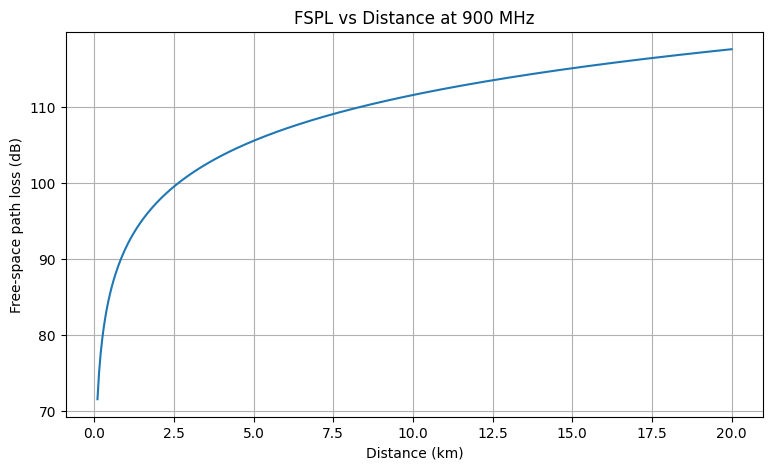

In [3]:
plt.figure(figsize=(9, 5))
plt.plot(distance_km, path_loss_db)
plt.xlabel("Distance (km)")
plt.ylabel("Free-space path loss (dB)")
plt.title(f"FSPL vs Distance at {frequency_mhz:.0f} MHz")
plt.grid(True)
plt.show()

**Observation:** FSPL increases with distance. Because the equation contains $20\log_{10}(d)$, a tenfold increase in distance adds 20 dB of free-space path loss.

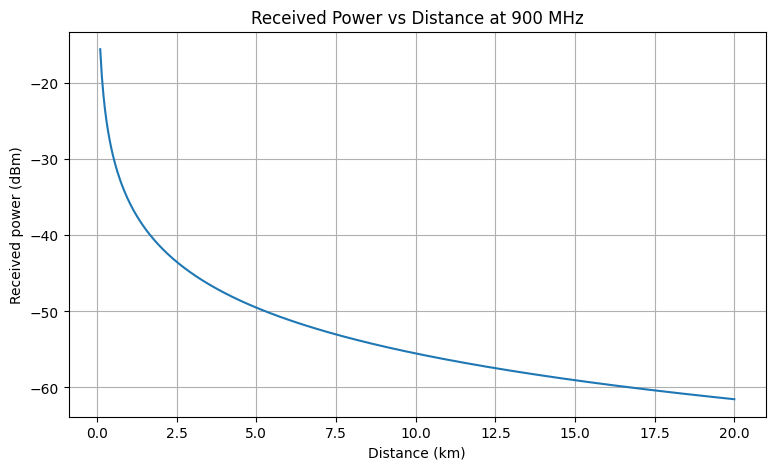

In [4]:
plt.figure(figsize=(9, 5))
plt.plot(distance_km, received_power_dbm)
plt.xlabel("Distance (km)")
plt.ylabel("Received power (dBm)")
plt.title(f"Received Power vs Distance at {frequency_mhz:.0f} MHz")
plt.grid(True)
plt.show()

**Observation:** Received power decreases as free-space path loss increases. Antenna gain raises the link budget, while additional losses reduce it.

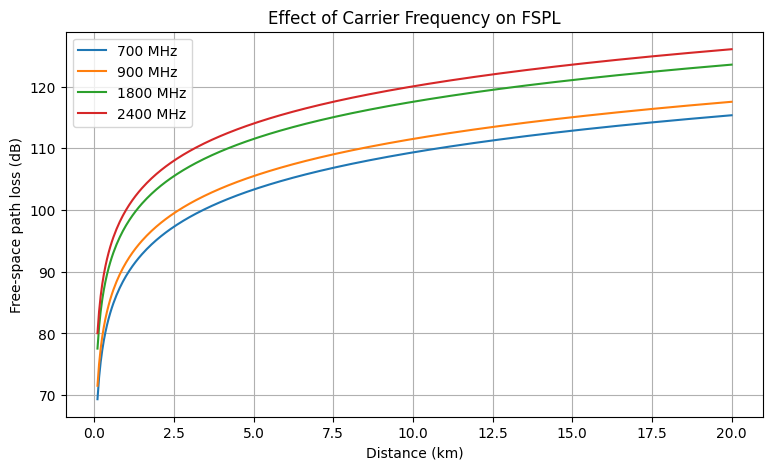

In [5]:
frequencies_mhz = [700, 900, 1800, 2400]

plt.figure(figsize=(9, 5))
for f_mhz in frequencies_mhz:
    plt.plot(distance_km, fspl_db(distance_km, f_mhz), label=f"{f_mhz} MHz")

plt.xlabel("Distance (km)")
plt.ylabel("Free-space path loss (dB)")
plt.title("Effect of Carrier Frequency on FSPL")
plt.legend()
plt.grid(True)
plt.show()

**Observation:** At the same distance, a higher carrier frequency has higher free-space path loss.

## Result and Discussion

The notebook verifies the expected free-space trends: path loss increases with both distance and frequency, while received power decreases as total link loss rises.

## Conclusion

Free-space path loss and received power were calculated and visualized successfully using Python as the implementation platform.

## Viva Questions and Short Answers

1. **When is the free-space model appropriate?**  
   For ideal unobstructed line-of-sight propagation.

2. **What happens to FSPL when distance increases by 10 times?**  
   It increases by 20 dB.

3. **What happens to FSPL when frequency increases?**  
   FSPL increases.

4. **What is the role of antenna gain in the link budget?**  
   Antenna gain increases the received power relative to an isotropic reference.

5. **Why must zero distance be avoided in the logarithmic formula?**  
   Because $\log_{10}(0)$ is undefined.